# XGBoost & LightGBM

## Assignment: Diabetes Classification Comparison

### Objective
Compare XGBoost and LightGBM performance on the Pima Indians Diabetes dataset.

### Dataset
768 records, 8 features, binary target (Outcome: 0=No Diabetes, 1=Diabetes).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette('Set2')

In [2]:
df = pd.read_csv('xgbm lgbm.csv')
print(f'Shape: {df.shape}')
print(f'\nTarget:\n{df["Outcome"].value_counts()}')
print(f'\nNulls: {df.isnull().sum().sum()}')

# Handle zero values in biological features
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
    df[col] = df[col].replace(0, df[df[col]!=0][col].median())
print(f'\nZero values imputed with median.')
df.describe()

Shape: (768, 9)

Target:
Outcome
0    500
1    268
Name: count, dtype: int64

Nulls: 0

Zero values imputed with median.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [3]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Train: 614, Test: 154


## XGBoost Model

In [4]:
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print('=== XGBOOST ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_xgb):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_xgb):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_xgb):.4f}')

=== XGBOOST ===
Accuracy:  0.7468
Precision: 0.6471
Recall:    0.6111
F1-Score:  0.6286


## LightGBM Model

In [5]:
lgb_model = lgb.LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)
y_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

print('=== LIGHTGBM ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_lgb):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lgb):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_lgb):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_lgb):.4f}')

=== LIGHTGBM ===
Accuracy:  0.7597
Precision: 0.6667
Recall:    0.6296
F1-Score:  0.6476


## Model Comparison

In [6]:
comparison = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM'],
    'Accuracy': [accuracy_score(y_test, y_pred_xgb), accuracy_score(y_test, y_pred_lgb)],
    'Precision': [precision_score(y_test, y_pred_xgb), precision_score(y_test, y_pred_lgb)],
    'Recall': [recall_score(y_test, y_pred_xgb), recall_score(y_test, y_pred_lgb)],
    'F1': [f1_score(y_test, y_pred_xgb), f1_score(y_test, y_pred_lgb)]
})
print(comparison.to_string(index=False))

   Model  Accuracy  Precision   Recall       F1
 XGBoost  0.746753   0.647059 0.611111 0.628571
LightGBM  0.759740   0.666667 0.629630 0.647619


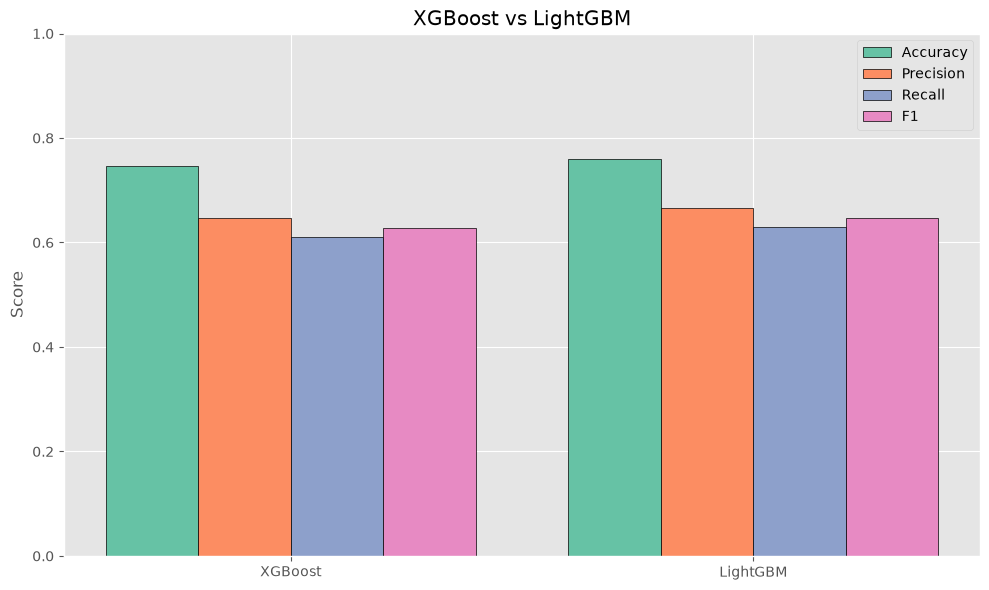

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(comparison))
width = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
for i, metric in enumerate(metrics):
    ax.bar(x_pos + i*width, comparison[metric], width, label=metric, edgecolor='black')
ax.set_xticks(x_pos + 1.5*width)
ax.set_xticklabels(comparison['Model'])
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('XGBoost vs LightGBM')
ax.legend()
plt.tight_layout()
plt.show()

## Feature Importance Comparison

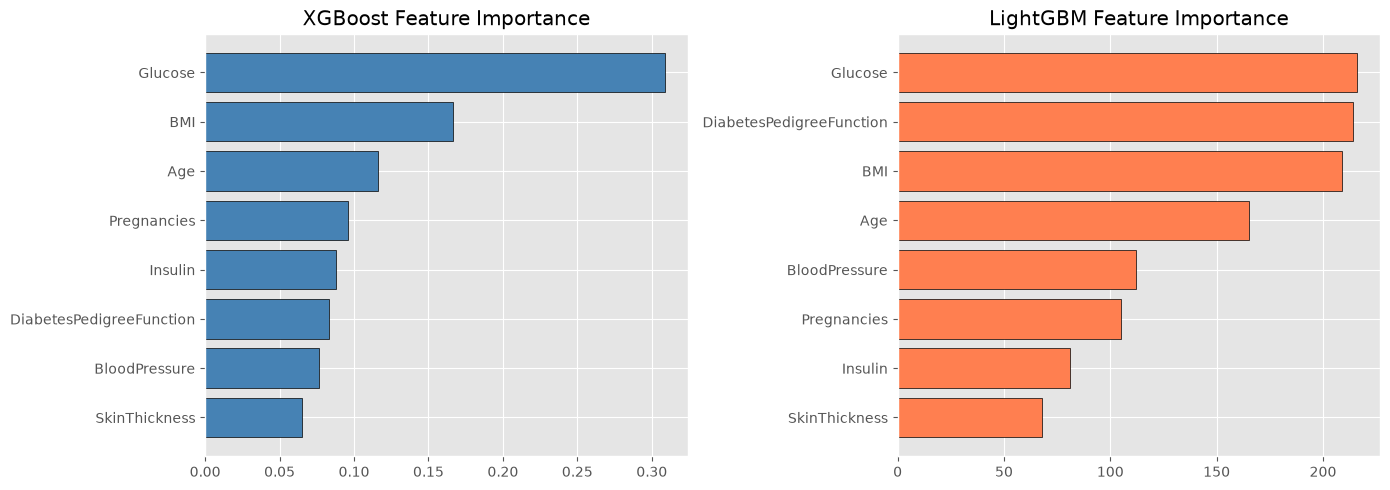

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

xgb_imp = pd.DataFrame({'Feature': X.columns, 'Importance': xgb_model.feature_importances_}).sort_values('Importance', ascending=True)
axes[0].barh(xgb_imp['Feature'], xgb_imp['Importance'], color='steelblue', edgecolor='black')
axes[0].set_title('XGBoost Feature Importance')

lgb_imp = pd.DataFrame({'Feature': X.columns, 'Importance': lgb_model.feature_importances_}).sort_values('Importance', ascending=True)
axes[1].barh(lgb_imp['Feature'], lgb_imp['Importance'], color='coral', edgecolor='black')
axes[1].set_title('LightGBM Feature Importance')

plt.tight_layout()
plt.show()

## Confusion Matrices

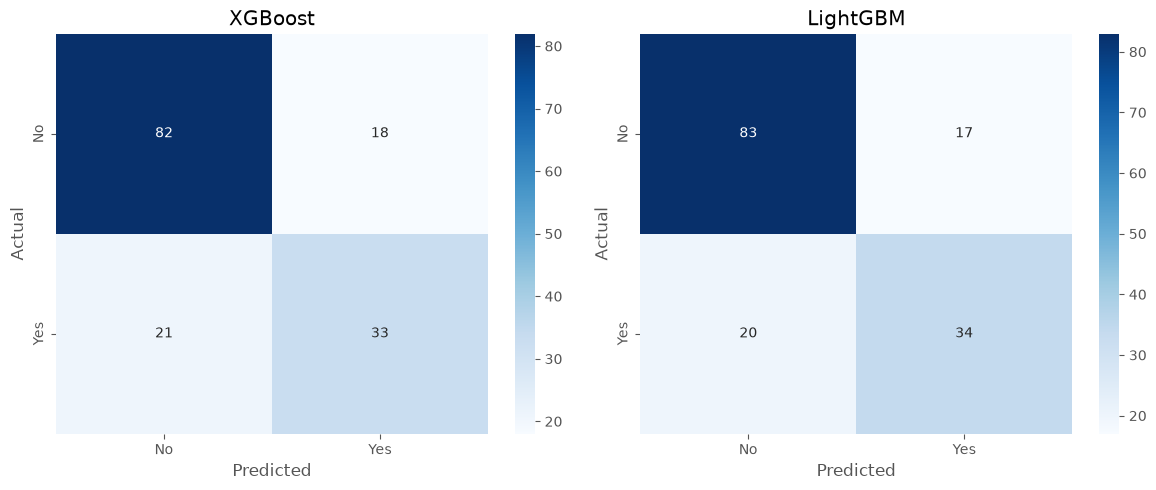

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[0].set_title('XGBoost')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_lgb = confusion_matrix(y_test, y_pred_lgb)
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Blues', ax=axes[1], xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[1].set_title('LightGBM')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Conclusion

- **XGBoost** and **LightGBM** both perform well on diabetes prediction
- **Glucose** is consistently the most important feature across both models
- LightGBM is generally faster to train (leaf-wise growth vs level-wise)
- XGBoost provides slightly better regularization by default
- Both gradient boosting frameworks outperform baseline logistic regression
- Either model is suitable for clinical diabetes screening deployment